In [82]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.ticker
from metpy.plots import SkewT
from metpy.units import units
from metpy.calc import dry_lapse, moist_lapse
import pandas as pd

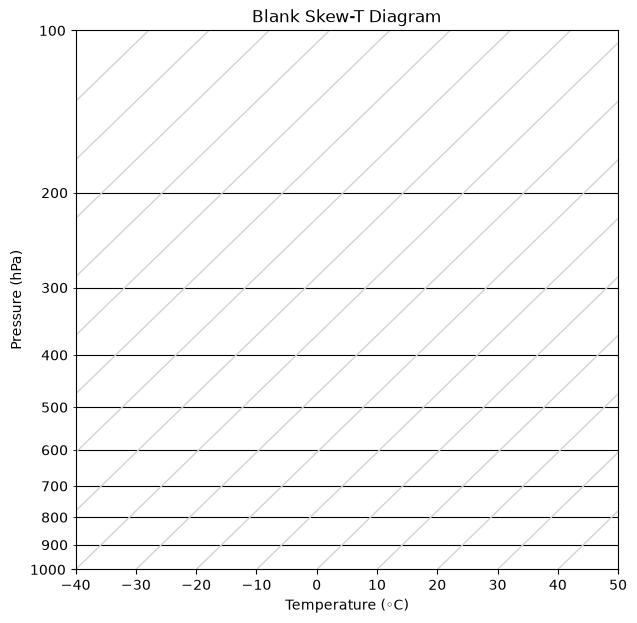

In [83]:
# blank SkewT with Isotherms
# Make the Figure
fig=plt.figure()
fig.set_size_inches(7,7)
ax=plt.axes()

# make Skew-T plot from 100 to 1000 hPa
ax.set_ylim(100,1000) 
#invert the y-axis and set the scale to logarithmic
ax.set_yinverted(True)
ax.set_yscale('log')
# add labels for 100 and 1000 hPa
ax.yaxis.set_major_formatter('{x:.0f}')
#add labels for 200,300,400,500,600,700,800,900 hPa
ax.yaxis.set_minor_formatter('{x:.0f}')
#add gridlines for hte y-axis
ax.grid(which='minor', axis='y', linestyle='-', color='k')

# Add axes and plot title
ax.set_title("Blank Skew-T Diagram")
ax.set_xlabel("Temperature (◦C)")
ax.set_ylabel("Pressure (hPa)")

#Set Temperature Limit 
ax.set_xlim(-40,50)

#SKEW FUNCTION CHANGED TO -40 TO MATCH WYOMING SOUNDING FOR VERIFICATION
def skewT(temp, pres, skew=-40): #Skews the temperature axis for a SkewT plot.
    #temp: temperature values (deg C)
    #pres: pressure values (hPa)
    #skew: amount of skew (default of -20)
    return (temp) + skew * np.log(pres/1000.0)
#for t in 

#Basic Temeprature and Pressure  variables to calculate isotherms
temperature = np.arange(-120, 60, 10)
pressure = np.linspace(100, 1000, 100)

# plot an isotherm for every point in the temperature array
for t in temperature:
    skewed=skewT(t, pressure)
    ax.plot(skewed, pressure, color='lightgray', linestyle='-', linewidth=1)


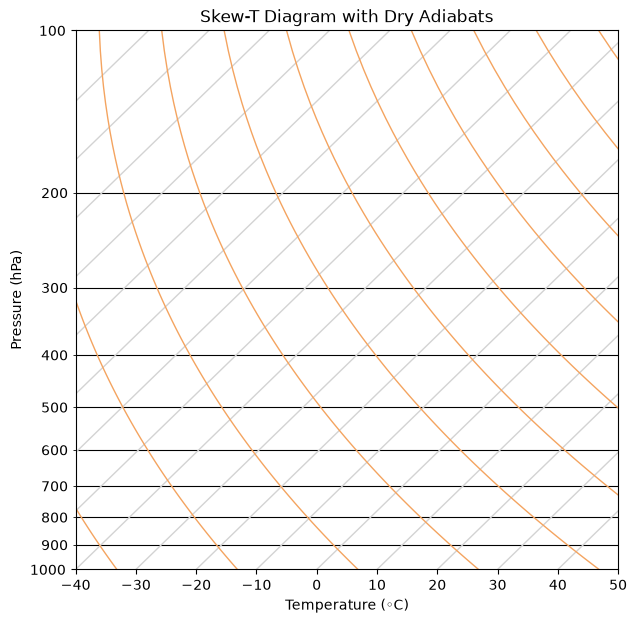

In [84]:
# SkewT with Isotherms and Dry Adiabats
# Make the Figure
fig=plt.figure()
fig.set_size_inches(7,7)
ax=plt.axes()

# make Skew-T plot from 100 to 1000 hPa
ax.set_ylim(100,1000) 
#invert the y-axis and set the scale to logarithmic
ax.set_yinverted(True)
ax.set_yscale('log')
# add labels for 100 and 1000 hPa
ax.yaxis.set_major_formatter('{x:.0f}')
#add labels for 200,300,400,500,600,700,800,900 hPa
ax.yaxis.set_minor_formatter('{x:.0f}')
#add gridlines for hte y-axis
ax.grid(which='minor', axis='y', linestyle='-', color='k')

# Add axes and plot title
ax.set_title("Skew-T Diagram with Dry Adiabats")
ax.set_xlabel("Temperature (◦C)")
ax.set_ylabel("Pressure (hPa)")

#Set Temperature Limit 
ax.set_xlim(-40,50)

#SKEW FUNCTION CHANGED TO -40 TO MATCH WYOMING SOUNDING FOR VERIFICATION
def skewT(temp, pres, skew=-40): #Skews the temperature axis for a SkewT plot.
    #temp: temperature values (deg C)
    #pres: pressure values (hPa)
    #skew: amount of skew (default of -20)
    return (temp) + skew * np.log(pres/1000.0)
#for t in 

#Basic Temeprature and Pressure  variables to calculate isotherms
temperature = np.arange(-120, 60, 10)
pressure = np.linspace(100, 1000, 100)

# plot an isotherm for every point in the temperature array
for t in temperature:
    skewed=skewT(t, pressure)
    ax.plot(skewed, pressure, color='lightgray', linestyle='-', linewidth=1)


#defining constants
rd= 287 #J kg−1 K−1,
cp= 1004 #J kg−1 K−1
eps=0.622 #ratio of the gas constants for dry air and water vapor
lv=2.5*10**6 #latent heat of vaporization (J/kg)

#theta values for dry adiabats 
d_theta= np.arange(200,600,20)

#dry adiabat equation, takes in theta and pressure and returns temperature
def dry_adiabat(theta, pres, init_pres=1000):
    return theta * ((pres/init_pres)**(rd/cp))


for theta in d_theta:
    #calculate the dry adiabat temperature for the given theta and pressure
    adi_temp= dry_adiabat(theta, pressure)
    #skew the dry adiabat temperature for plotting
    adi_temp_sk=skewT(adi_temp-273.15, pressure)
    #plot dry adiabats
    ax.plot(adi_temp_sk, pressure, color='sandybrown', linestyle='-', linewidth=1)



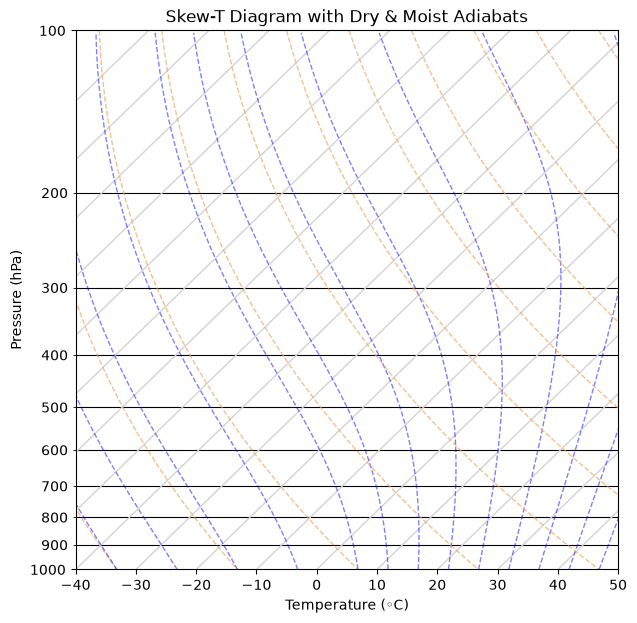

In [85]:

# SkewT with Isotherms, Dry Adiabats and Moist Adiabats
# Make the Figure
fig=plt.figure()
fig.set_size_inches(7,7)
ax=plt.axes()

# make Skew-T plot from 100 to 1000 hPa
ax.set_ylim(100,1000) 
#invert the y-axis and set the scale to logarithmic
ax.set_yinverted(True)
ax.set_yscale('log')
# add labels for 100 and 1000 hPa
ax.yaxis.set_major_formatter('{x:.0f}')
#add labels for 200,300,400,500,600,700,800,900 hPa
ax.yaxis.set_minor_formatter('{x:.0f}')
#add gridlines for hte y-axis
ax.grid(which='minor', axis='y', linestyle='-', color='k')

# Add axes and plot title
ax.set_title("Skew-T Diagram with Dry & Moist Adiabats")
ax.set_xlabel("Temperature (◦C)")
ax.set_ylabel("Pressure (hPa)")

#Set Temperature Limit 
ax.set_xlim(-40,50)

#SKEW FUNCTION CHANGED TO -40 TO MATCH WYOMING SOUNDING FOR VERIFICATION
def skewT(temp, pres, skew=-40): #Skews the temperature axis for a SkewT plot.
    #temp: temperature values (deg C)
    #pres: pressure values (hPa)
    #skew: amount of skew (default of -20)
    return (temp) + skew * np.log(pres/1000.0)
#for t in 

#Basic Temeprature and Pressure  variables to calculate isotherms
temperature = np.arange(-120, 60, 10)
pressure = np.linspace(100, 1000, 100)

# plot an isotherm for every point in the temperature array
for t in temperature:
    skewed=skewT(t, pressure)
    ax.plot(skewed, pressure, color='lightgray', linestyle='-', linewidth=1)

#defining constants
rd= 287 #J kg−1 K−1,
cp= 1004 #J kg−1 K−1
eps=0.622 #ratio of the gas constants for dry air and water vapor
lv=2.5*10**6 #latent heat of vaporization (J/kg)

#theta values for dry adiabats 
d_theta= np.arange(200,600,5)

#dry adiabat equation, takes in theta and pressure and returns temperature
def dry_adiabat(theta, pres, init_pres=1000):
    return theta * ((pres/init_pres)**(rd/cp))


#change moist adiabat eqn to pressure coordinates -> use HB and multiple by RdT/pg
 
# moist adabat equation in pressure coordinates, takes in temperature and pressure and returns dT/dp
def moist_adiabat(temp, pres):
    #saturation vapor pressure
    es=6.112*(np.exp(17.67*((temp-273.15)/(temp-29.65)))) #hPa
    #rs calculation 
    rs=eps*(es/(pres-es)) #kg/kg
    #numerator and denominator for the moist adiabatic lapse rate equation
    theta_z_num=1+((lv*rs)/(rd*temp))
    theta_z_den=1+((rs*(lv**2))/(cp*rv*(temp**2)))
    #combining 
    theta_z=(-g/cp)* (theta_z_num/theta_z_den)
    #converting to pressure coordinates
    theta_p= -theta_z*((rd*temp)/(pres*g))
    return theta_p

#pressure array that includes every milibar from 1000 to 100 hPa, used for numerical integration of the moist adiabat
hi_res_p=np.arange(100,1000,1)
#reverse array of above
hi_res_p2=np.arange(1000,100,-1)
#print(hi_res_p2)    #calculate the dry adiabat temperature for the given theta and pressure
  


for theta in d_theta:
    adi_temp= dry_adiabat(theta, pressure)
    #skew the dry adiabat temperature for plotting
    adi_temp_sk=skewT(adi_temp-273.15, pressure)
    #calculating the inital dT/dp at 1000mb for the inital temperature of the dry adiabat
    adi_moist=moist_adiabat(adi_temp[-1],1000)
    #list of temperaturevalues for the moist adiabat.
    adi_moist_2=[]
    #adding the inital temperature of the dry adiabat (converted to C)
    adi_moist_2.append(adi_temp[-1]-273.15)
    #setting inital values for our loop
    temp_interate=adi_temp[-1]-273.15

    #numeric integration for each mb between 1000 and 100 hPa
    for pres in list(range(len(hi_res_p2))):
        #Subtracting the moist adiabatic lapse rate from the previous temperature to get the next temperature
        temp_interate = temp_interate-adi_moist
        #adding it to the list
        adi_moist_2.append(temp_interate)
        #recalculating the moist adiabatic lapse rate for the new temperature and pressure
        adi_moist=moist_adiabat(temp_interate+273.15,hi_res_p2[pres])
    #skewing the moist adiabat for plotting
    adi_moist_sk=skewT(adi_moist_2[:-1],hi_res_p2)

    #plotting every 4th dry adiabat
    if theta%4 ==0:
        ax.plot(adi_temp_sk, pressure, color='sandybrown', linestyle='--', linewidth=1,alpha=.7)
    #plotting all moist adiabats above 280K and every other one below 280K
    if theta > 280:
        ax.plot(adi_moist_sk, hi_res_p2, color='blue', linestyle='--', linewidth=1,alpha=.5)
    elif theta %2 ==0:
        ax.plot(adi_moist_sk, hi_res_p2, color='blue', linestyle='--', linewidth=1,alpha=.5)




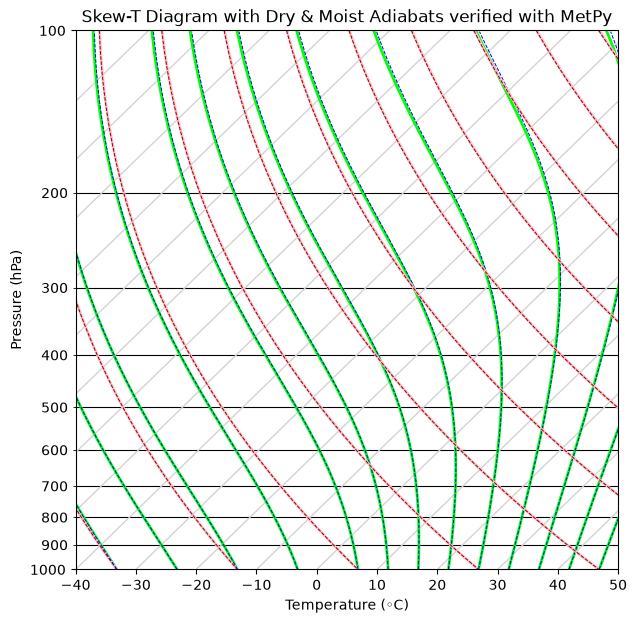

In [105]:
#Verifying the moist adiabats by comparing to the MetPy moist_lapse function
#Metpy is a trusted meteological python librrary, with it's descriptive BAMS article receving over nearly 100 citations since publication in 2022.  

#MetPy Citation:
#May, R. M., and Coauthors, 2022: MetPy: A Meteorological Python Library for Data Analysis and Visualization. 
#     Bull. Amer. Meteor. Soc., 103, E2273–E2284, https://doi.org/10.1175/BAMS-D-21-0125.1.


# SkewT with Isotherms, Dry Adiabats and Moist Adiabats
# Make the Figure
fig=plt.figure()
fig.set_size_inches(7,7)
ax=plt.axes()

# make Skew-T plot from 100 to 1000 hPa
ax.set_ylim(100,1000) 
#invert the y-axis and set the scale to logarithmic
ax.set_yinverted(True)
ax.set_yscale('log')
# add labels for 100 and 1000 hPa
ax.yaxis.set_major_formatter('{x:.0f}')
#add labels for 200,300,400,500,600,700,800,900 hPa
ax.yaxis.set_minor_formatter('{x:.0f}')
#add gridlines for hte y-axis
ax.grid(which='minor', axis='y', linestyle='-', color='k')

# Add axes and plot title
ax.set_title("Skew-T Diagram with Dry & Moist Adiabats verified with MetPy")
ax.set_xlabel("Temperature (◦C)")
ax.set_ylabel("Pressure (hPa)")

#Set Temperature Limit 
ax.set_xlim(-40,50)

#SKEW FUNCTION CHANGED TO -40 TO MATCH WYOMING SOUNDING FOR VERIFICATION
def skewT(temp, pres, skew=-40): #Skews the temperature axis for a SkewT plot.
    #temp: temperature values (deg C)
    #pres: pressure values (hPa)
    #skew: amount of skew (default of -20)
    return (temp) + skew * np.log(pres/1000.0)
#for t in 

#Basic Temeprature and Pressure  variables to calculate isotherms
temperature = np.arange(-120, 60, 10)
pressure = np.linspace(100, 1000, 100)
pressure_inv=np.arange(1000,90,-10)

# plot an isotherm for every point in the temperature array
for t in temperature:
    skewed=skewT(t, pressure)
    ax.plot(skewed, pressure, color='lightgray', linestyle='-', linewidth=1)

#defining constants
rd= 287 #J kg−1 K−1,
cp= 1004 #J kg−1 K−1
eps=0.622 #ratio of the gas constants for dry air and water vapor
lv=2.5*10**6 #latent heat of vaporization (J/kg)

#theta values for dry adiabats 
d_theta= np.arange(200,600,5)

#dry adiabat equation, takes in theta and pressure and returns temperature
def dry_adiabat(theta, pres, init_pres=1000):
    return theta * ((pres/init_pres)**(rd/cp))


#change moist adiabat eqn to pressure coordinates -> use HB and multiple by RdT/pg
 
# moist adabat equation in pressure coordinates, takes in temperature and pressure and returns dT/dp
def moist_adiabat(temp, pres):
    #saturation vapor pressure
    es=6.112*(np.exp(17.67*((temp-273.15)/(temp-29.65)))) #hPa
    #rs calculation 
    rs=eps*(es/(pres-es)) #kg/kg
    #numerator and denominator for the moist adiabatic lapse rate equation
    theta_z_num=1+((lv*rs)/(rd*temp))
    theta_z_den=1+((rs*(lv**2))/(cp*rv*(temp**2)))
    #combining 
    theta_z=(-g/cp)* (theta_z_num/theta_z_den)
    #converting to pressure coordinates
    theta_p= -theta_z*((rd*temp)/(pres*g))
    return theta_p

#pressure array that includes every milibar from 1000 to 100 hPa, used for numerical integration of the moist adiabat
hi_res_p=np.arange(100,1000,1)
#reverse array of above
hi_res_p2=np.arange(1000,100,-0.5)
#print(hi_res_p2)    #calculate the dry adiabat temperature for the given theta and pressure
  


for theta in d_theta:
    #calcuate the dry adiabat temperature for the given theta and pressure
    adi_temp= dry_adiabat(theta, pressure)
    #skew the dry adiabat temperature for plotting
    adi_temp_sk=skewT(adi_temp-273.15, pressure)
    #comparing with metpy's dry_lapse function
    metpy_dry=dry_lapse((pressure_inv * units.hPa),((adi_temp[-1]-273.15)* units.degC)).to('degC')
    metpy_dry=metpy_dry.magnitude
    #skewing
    metpy_dry_sk=skewT(metpy_dry,pressure_inv)
    #calculating the inital dT/dp at 1000mb for the inital temperature of the dry adiabat
    adi_moist=moist_adiabat(adi_temp[-1],1000)
    #list of temperaturevalues for the moist adiabat.
    adi_moist_2=[]
    #adding the inital temperature of the dry adiabat (converted to C)
    adi_moist_2.append(adi_temp[-1]-273.15)
    #setting inital values for our loop
    temp_interate=adi_temp[-1]-273.15
    #calculating the moist adiabatic lapse rate using the MetPy function for comparison
    metpy_moist=moist_lapse((hi_res_p2 * units.hPa), ((adi_temp[-1]-273.15) * units.degC)).to('degC')
    #skewing the metpy moist adiabats for plotting
    metpy_moist=metpy_moist.magnitude
    metpy_moist_sk=skewT(metpy_moist,hi_res_p2)
    #plotting metpy moist adiabats the same as my moist adiabats below
    if theta > 280:
        ax.plot(metpy_moist_sk, hi_res_p2, color='lime', linestyle='-', linewidth=2,alpha=1)
    elif theta %2 ==0:
        ax.plot(metpy_moist_sk, hi_res_p2, color='lime', linestyle='-', linewidth=2,alpha=1)
        #plotting metpy dry adiabats the same as my moist adiabats below
   #plotting metpy dry adiabats the same as my dry adibats below
    if theta %4 ==0: #linewidth =2 to see overlay with my dry adibats
        ax.plot(metpy_dry_sk, pressure_inv, color='pink', linestyle='-', linewidth=2,alpha=1)
    #numeric integration for each 0.5 mb between 1000 and 100 hPa
    for pres in list(range(len(hi_res_p2))):
        #Subtracting the moist adiabatic lapse rate from the previous temperature to get the next temperature
        temp_interate = temp_interate-(adi_moist*.5)
        #adding it to the list
        adi_moist_2.append(temp_interate)
        #recalculating the moist adiabatic lapse rate for the new temperature and pressure
        adi_moist=moist_adiabat(temp_interate+273.15,hi_res_p2[pres])
    #skewing the moist adiabat for plotting
    adi_moist_sk=skewT(adi_moist_2[:-1],hi_res_p2)

    #plotting every 4th dry adiabat
    if theta%4 ==0: # color changed to black for visual clarity
        ax.plot(adi_temp_sk, pressure, color='darkred', linestyle='--', linewidth=0.7,alpha=1)
    #plotting all moist adiabats above 280K and every other one below 280K
    if theta > 280:
        ax.plot(adi_moist_sk, hi_res_p2, color='blue', linestyle='--', linewidth=0.7,alpha=1)
    elif theta %2 ==0:
        ax.plot(adi_moist_sk, hi_res_p2, color='blue', linestyle='--', linewidth=0.7,alpha=1)




Dry and moist adiabats were verified by comparing to the MetPy dry_lapse and moist_lapse functions, respectively. MetPy is a trusted meteorological Python library, with its descriptive BAMS article receiving nearly 100 citations since publication in 2022. Therefore, it is a great tool to compare my numerical solution to. 

MetPy Citation:
May, R. M., and Coauthors, 2022: MetPy: A Meteorological Python Library for Data Analysis and Visualization. 
      Bull. Amer. Meteor. Soc., 103, E2273–E2284, https://doi.org/10.1175/BAMS-D-21-0125.1.

As we can see above, there is complete agreement between my dry adiabats (dashed dark red lines) and the MetPy dry adiabats (solid light pink lines), which indicates that my numerical solution is a great representation of the isentropes and the dry adiabatic lapse rate. *NOTE*  In this plot only, the dry adiabats are dark red dashed lines to improve the visual comparison of my dry adiabats and the MetPy dry adiabats. Every other skew-T has the dry adiabats as "sandybrown."

My moist adiabats (dashed blue lines) are in near complete agreement with the MetPy moist adiabats (solid green lines) as well. We only see slight deviation above 200 mb. This can be expected because MetPy integrates the moist adiabatic lapse rate function, while my numerical solution does not. With the logarithmic scale, my step size becomes much larger than MetPy's above 200 mb, which likely leads to this slight deviation between the two. When I decrease the step size from 1mb to 0.5mb (step size 0.5 mb is the plot above; step size 1 mb is the first plot with moist adiabats), the deviation decreases. 

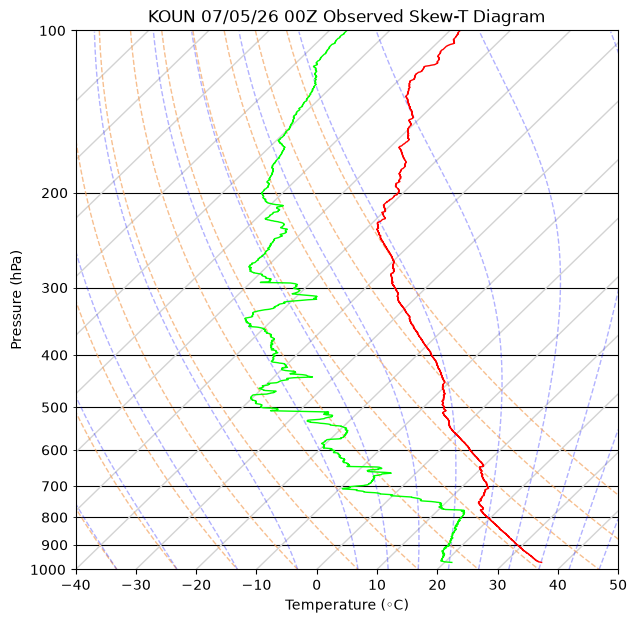

In [87]:
# SkewT with Isotherms, Dry Adiabats, Moist Adiabats, and a sounding T/Td data
# Make the Figure
fig=plt.figure()
fig.set_size_inches(7,7)
ax=plt.axes()

# make Skew-T plot from 100 to 1000 hPa
ax.set_ylim(100,1000) 
#invert the y-axis and set the scale to logarithmic
ax.set_yinverted(True)
ax.set_yscale('log')
# add labels for 100 and 1000 hPa
ax.yaxis.set_major_formatter('{x:.0f}')
#add labels for 200,300,400,500,600,700,800,900 hPa
ax.yaxis.set_minor_formatter('{x:.0f}')
#add gridlines for hte y-axis
ax.grid(which='minor', axis='y', linestyle='-', color='k')

# Add axes and plot title
ax.set_title("KOUN 07/05/26 00Z Observed Skew-T Diagram")
ax.set_xlabel("Temperature (◦C)")
ax.set_ylabel("Pressure (hPa)")

#Set Temperature Limit 
ax.set_xlim(-40,50)

#SKEW FUNCTION CHANGED TO -40 TO MATCH WYOMING SOUNDING FOR VERIFICATION
def skewT(temp, pres, skew=-40): #Skews the temperature axis for a SkewT plot.
    #temp: temperature values (deg C)
    #pres: pressure values (hPa)
    #skew: amount of skew (default of -20)
    return (temp) + skew * np.log(pres/1000.0)
#for t in 

#Basic Temeprature and Pressure  variables to calculate isotherms
temperature = np.arange(-120, 60, 10)
pressure = np.linspace(100, 1000, 100)

# plot an isotherm for every point in the temperature array
for t in temperature:
    skewed=skewT(t, pressure)
    ax.plot(skewed, pressure, color='lightgray', linestyle='-', linewidth=1)

#defining constants
rd= 287 #J kg−1 K−1,
cp= 1004 #J kg−1 K−1
eps=0.622 #ratio of the gas constants for dry air and water vapor
lv=2.5*10**6 #latent heat of vaporization (J/kg)

#theta values for dry adiabats 
d_theta= np.arange(200,350,5)

#dry adiabat equation, takes in theta and pressure and returns temperature
def dry_adiabat(theta, pres, init_pres=1000):
    return theta * ((pres/init_pres)**(rd/cp))


#change moist adiabat eqn to pressure coordinates -> use HB and multiple by RdT/pg
 
# moist adabat equation in pressure coordinates, takes in temperature and pressure and returns dT/dp
def moist_adiabat(temp, pres):
    #saturation vapor pressure
    es=6.112*(np.exp(17.67*((temp-273.15)/(temp-29.65)))) #hPa
    #rs calculation 
    rs=eps*(es/(pres-es)) #kg/kg
    #numerator and denominator for the moist adiabatic lapse rate equation
    theta_z_num=1+((lv*rs)/(rd*temp))
    theta_z_den=1+((rs*(lv**2))/(cp*rv*(temp**2)))
    #combining 
    theta_z=(-g/cp)* (theta_z_num/theta_z_den)
    #converting to pressure coordinates
    theta_p= -theta_z*((rd*temp)/(pres*g))
    return theta_p

#pressure array that includes every milibar from 1000 to 100 hPa, used for numerical integration of the moist adiabat
hi_res_p=np.arange(100,1000,1)
#reverse array of above
hi_res_p2=np.arange(1000,100,-.5)
#print(hi_res_p2)


for theta in d_theta:
    #calculate the dry adiabat temperature for the given theta and pressure
    adi_temp= dry_adiabat(theta, pressure)
    #skew the dry adiabat temperature for plotting
    adi_temp_sk=skewT(adi_temp-273.15, pressure)
    #calculating the inital dT/dp at 1000mb for the inital temperature of the dry adiabat
    adi_moist=moist_adiabat(adi_temp[-1],1000)
    #list of temperaturevalues for the moist adiabat.
    adi_moist_2=[]
    #adding the inital temperature of the dry adiabat (converted to C)
    adi_moist_2.append(adi_temp[-1]-273.15)
    #setting inital values for our loop
    temp_interate=adi_temp[-1]-273.15

    #numeric integration for each 0.5 mb between 1000 and 100 hPa
    for pres in list(range(len(hi_res_p2))):
        #Subtracting the moist adiabatic lapse rate from the previous temperature to get the next temperature
        temp_interate = temp_interate-(adi_moist*.5)
        #adding it to the list
        adi_moist_2.append(temp_interate)
        #recalculating the moist adiabatic lapse rate for the new temperature and pressure
        adi_moist=moist_adiabat(temp_interate+273.15,hi_res_p2[pres])
    #skewing the moist adiabat for plotting
    adi_moist_sk=skewT(adi_moist_2[:-1],hi_res_p2)

    #plotting every other dry adiabat
    if theta%2 ==0:
        ax.plot(adi_temp_sk, pressure, color='sandybrown', linestyle='--', linewidth=1,alpha=.7)
    #plotting all moist adiabats above 280K and every other one below 280K
    if theta > 280:
        ax.plot(adi_moist_sk, hi_res_p2, color='blue', linestyle='--', linewidth=1,alpha=.3)
    elif theta %2 ==0:
        ax.plot(adi_moist_sk, hi_res_p2, color='blue', linestyle='--', linewidth=1,alpha=.3)

#loading in real sounding data
koun=pd.read_csv('2026070500-72357.csv')
#koun
#defining T, Td, and P variables from the sounding data
obs_t=koun['temperature_C']
obs_td=koun['dew point temperature_C']
obs_p=koun['pressure_hPa']
# skewing observed temperature and dew point temperature for plotting
skewed_obs=skewT(obs_t, obs_p)
skewed_obs_td=skewT(obs_td, obs_p)
#plotting observed data
ax.plot(skewed_obs, obs_p, color='red', linestyle='-', linewidth=1)
ax.plot(skewed_obs_td, obs_p, color='lime', linestyle='-', linewidth=1)

Sounding from the University of Wyoming for Reference. I picked Skew= -40 to match this sounding. This sounding was used as an additional verification tool. Visual similarities between my sounding and the sounding below provie a great final sanity check before moving onto the interpretation questions

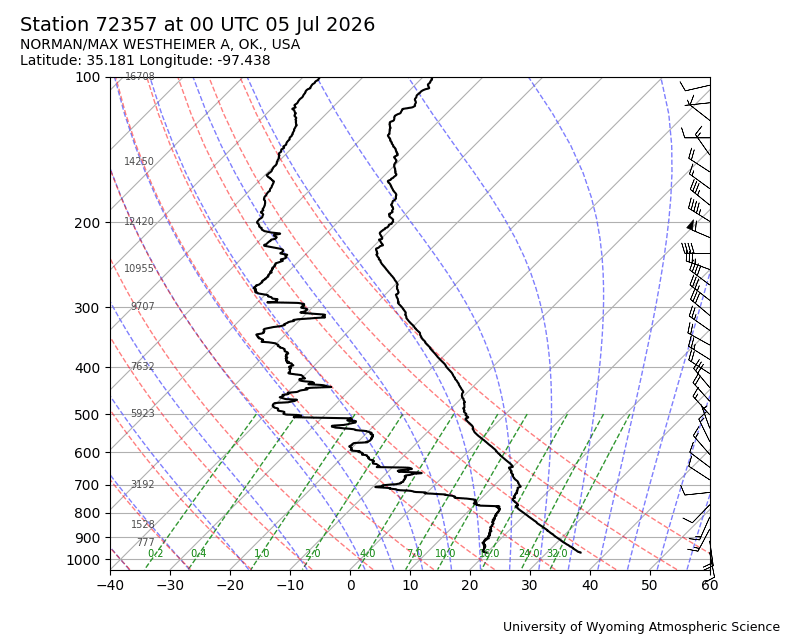

Interpretation prompts:
1. Why does the moist adiabatic lapse rate, Γm = −dT /dz, generally increase as a saturated parcel ascends and cools?

As a saturated parcel ascends and cools, the saturation vapor pressure decreases. Therefore, a phase change (i.e., condensation) must occur, which adds an additional heat source from latent heating. This latent heating from condensation decreases the rate at which an ascending parcel cools. 

The relationship between temperature and saturation vapor pressure is exponential; a cold parcel will have a smaller change in saturation vapor pressure than a warm parcel if they experience the same dT. Since ascending cold parcels experience a smaller change in saturation vapor pressure (des/dT), they will experience less condensational heating and cool much closer to the dry adiabatic lapse rate than a warm parcel.

2. At a fixed pressure, how and why does Γm differ between warmer and colder moist adiabats?

At a fixed pressure, for example, 1000 hPa, we see very different slopes in Γm. These slopes are a result of the exponential relationship between temperature and saturation vapor pressure. Saturation vapor pressure is built into the Γm equation; therefore, the Clausius-Clapeyron equation will impact the slope of the moist adiabats at a given level. As explained in question 1, warmer parcels have a higher des/dT than cooler parcels. So, this will manifest as a greater deviation of Γm from Γd for warmer moist adiabats.

Additionally, for rs (saturation mixing ratio) values near zero, the Γm equation becomes the differential form of poisson's equation. This is why we see the colder moist adiabats parallel the dry adiabats, because cold parcels have saturation mixing ratios near 0.


3. “Break” your SkewT: test a wide range of skew values and describe what happens to the plot. What does this test teach you about the value of skewing? No need to show your tests; just describe your interpretations.


We intentionally skew temperature on the skew-T plots to improve visual interpretation for forecasting and analysis. In my observed case, the correct skew is crucial. With a skew greater than -30 (e.g., skew = -20), the observed dewpoint temperatures are off the plot. Moreover, with skew = 0, observed temperature is also off the plot. The inability for data to "fit" would obviously hamper human interpretation. Further examining skew = -20, the capping inversion is no longer visible. This would be crucial for forecasting convective initiation and maintenance because parcels need to overcome this cap. Additionally, the inverted-V in the low-levels becomes less apparent. This feature is very important for forecasting downbursts and microbursts. So losing visual interpretation of this feature could be detrimental. 

Linking back to questions 1&2, with a greater, or less negative, skew we start to lose curvature in the moist adiabats. This decreases our ability to see the change in Γm curvative from Clausius-Clapeyron. Losing this curvature makes parcels appear less buoyant (i.e., CAPE is less visible). This could also have major implications for forecasting updraft strength and longevity. 

In conclusion, we lose interpretability for many major features in our skew-T with the "broken" skew values. While this would not have an impact on computer interpretation, it could have vast impacts on human interpretation.



4. Describe two features of the sounding you chose to plot that you find particularly interesting or useful. Refer to specific pressure levels or layers and explain the physical significance of each feature.

I chose this sounding for the inverted-V seen between 1000 and 800 mb, with the greatest dewpoint depression at the surface. This feature is usually associated with damaging winds (including downbursts) if convective storms are supported, or virga for weaker forced stratiform precipitation. In this case, the steep lapse rates and wind shear (not pictured) supported a convective line which produced 90 mph wind gusts in Norman (recorded by the Oklahoma Mesonet). In this case, the inverted-V was crucial for forecasting this event (as mentioned in question 3). 

The second feature that I thought was interesting was the capping inversion from 800—620 hPa. This inversion would impact storm initiation and maintenance due to this layer hindering surface parcel buoyancy. The storm began to dissipate fairly soon after passing through Norman, which could have been in part due to the capping inversion. As mentioned in question 3, you lose this feature with certain skews, which would impact the storm longevity forecasts.


5. What was the most challenging step for this lab? How did you navigate it, and what was the solution? If you leaned on GenAI tools, how did they contribute to your work and how did you check the information they provided?

I had trouble calculating lines of constant θ for my dry adiabats. When I created my original function, it iterated over constant temperatures rather than constant θ. After attending office hours, I finally understood to switch the arguments and iterate over constant θ, to find the temperatures associated with this θ at each pressure level.


I also had some trouble with the moist adiabats since I had to apply the formula in a different way than the dry adiabats. After discussing in office hours and clarifying with my peers, I found that I could add a nested loop to input the 1000mb θ for each dry adiabat into the moist adiabat function. Since the function returned a dT/dp, I subtracted the lapse rate for each millibar increase in the atmosphere until 100mb. Essentially, this was a numerical solution instead of integrating the dT/dp equation. I ended up verifying my moist adiabats with the MetPy-calculated adiabats. At first, my moist adiabats looked a bit off, but then I changed my step size to 0.5 hPa, and they matched! 